# Discovering and Accessing Theoretical Stellar Spectral Libraries

The SVO Theory Server hosts 70 collections of theoretical stellar spectra and observational templates, providing access to approximately 285,000 spectra and 668 GB of data.

This notebook allows users to explore the available collections of theoretical data, search for spectra based on grid parameter ranges, visualize the results, and download the selected spectra in ASCII or VOTable format.

**Data source:** http://svo2.cab.inta-csic.es/theory/newov2/index.php  


## 1. Install dependencies
*(run only once)*

In [1]:
%pip install -q requests beautifulsoup4 pandas matplotlib numpy plotly


[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import pandas as pd
import time, json, os, re
import plotly.graph_objects as go
import numpy as np
import json
from bs4 import BeautifulSoup
from IPython.display import display, HTML

# SVO Theory Server base URL
BASE_URL  = 'http://svo2.cab.inta-csic.es/theory/newov2/index.php'
# URL for downloading individual spectra
SSAP_URL  = 'http://svo2.cab.inta-csic.es/theory/newov2/ssap.php'
print('Libraries loaded')

Libraries loaded


In [3]:
with open('svo_stellar_spectra_models.json') as f:
    data = json.load(f)

df_collections = pd.DataFrame(data)
print(f'{len(df_collections)} collections loaded')

43 collections loaded


## 2. Load collections from the API

Data is retrieved from the **internal API**, which queries the database directly.

In [4]:
# Data source — choose one:
# 'api'  → loads from the internal API (requires Tomcat running)
# 'json' → loads from a local JSON file (works offline, no dependencies)
DATA_SOURCE = 'json'
JSON_FILE   = 'svo_stellar_spectra_models.json'


def load_from_api():
    """
    Queries the internal API, which returns parameter ranges
    for each collection directly from the database.
    """
    resp = requests.get(API_URL, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    records = []
    for item in data:
        ranges = item.get('paramRanges', {})
        records.append({
            'model_id': item['name'],
            'name':     item['title'],
            'teff_min': ranges.get('teff', {}).get('min'),
            'teff_max': ranges.get('teff', {}).get('max'),
            'logg_min': ranges.get('logg', {}).get('min'),
            'logg_max': ranges.get('logg', {}).get('max'),
            'feh_min':  ranges.get('meta', {}).get('min'),
            'feh_max':  ranges.get('meta', {}).get('max'),
            'teff_options': [],
            'logg_options': [],
            'desc': item.get('desc'),
            'url':  f'{BASE_URL}?models={item["name"]}',
        })
    return records


def load_from_json(path=JSON_FILE):
    """
    Loads collection data from a local JSON file.
    Useful when the internal API is not available.
    The JSON file can be generated once using load_from_api() + export.
    """
    with open(path) as f:
        return json.load(f)


def load_collections():
    """
    Main entry point. Loads collections from the configured data source.
    Change DATA_SOURCE above to switch between 'api' and 'json'.
    """
    if DATA_SOURCE == 'api':
        print('Loading from API...')
        return load_from_api()
    else:
        print(f'Loading from JSON ...{JSON_FILE}...')
        return load_from_json()


# Load collections
df_collections = pd.DataFrame(load_collections())

Loading from JSON ...svo_stellar_spectra_models.json...


---
# Phase 1 — Discovery
## Req 1: Which collections have data in my parameter range?

*Edit the values below and run the cells.*

In [5]:
# Search parameters — edit these values
TEFF_MIN =  3000.0   # Minimum effective temperature (K) — None to skip
TEFF_MAX =  7000.0   # Maximum effective temperature (K) — None to skip

LOGG_MIN =    3.5    # Minimum log(g) — None to skip
LOGG_MAX =    5.0    # Maximum log(g) — None to skip

FEH_MIN  =   -1.0    # Minimum metallicity [M/H] — None to skip
FEH_MAX  =    0.5    # Maximum metallicity [M/H] — None to skip

In [6]:
# Helper functions
def fmt(v): return '—' if v is None else f'{v:g}'
def fmt_range(mn, mx):
    if mn is None and mx is None: return 'N/D'
    if mn == mx and mn is not None: return f'{fmt(mn)}'
    return f'{fmt(mn)} – {fmt(mx)}'

def ranges_overlap(col_min, col_max, search_min, search_max):
    if search_min is None and search_max is None: return True
    if col_min is None or col_max is None: return True
    if search_max is not None and col_min > search_max: return False
    if search_min is not None and col_max < search_min: return False
    return True

# Filter collections
mask = df_collections.apply(lambda r: (
    ranges_overlap(r.teff_min, r.teff_max, TEFF_MIN, TEFF_MAX) and
    ranges_overlap(r.logg_min, r.logg_max, LOGG_MIN, LOGG_MAX) and
    ranges_overlap(r.feh_min,  r.feh_max,  FEH_MIN,  FEH_MAX)
), axis=1)
df_result = df_collections[mask].reset_index(drop=True)

# Display results table
df_tabla = df_result.copy()
df_tabla['Teff (K)'] = df_tabla.apply(lambda r: fmt_range(r.teff_min, r.teff_max), axis=1)
df_tabla['log(g)']   = df_tabla.apply(lambda r: fmt_range(r.logg_min, r.logg_max), axis=1)
df_tabla['[M/H]']    = df_tabla.apply(lambda r: fmt_range(r.feh_min,  r.feh_max),  axis=1)
df_tabla['Link']     = df_tabla['url'].apply(lambda u: f'<a href="{u}" target="_blank">View</a>')
df_display = df_tabla[['name','Teff (K)','log(g)','[M/H]','Link']].rename(columns={'name': 'Collection'})
df_display.index += 1

print(f'{len(df_result)} collections found for '
      f'Teff [{TEFF_MIN}–{TEFF_MAX} K] · log(g) [{LOGG_MIN}–{LOGG_MAX}] · [M/H] [{FEH_MIN}–{FEH_MAX}]\n')
display(HTML(df_display.to_html(escape=False, index=True)))

22 collections found for Teff [3000.0–7000.0 K] · log(g) [3.5–5.0] · [M/H] [-1.0–0.5]



,Collection,Teff (K),log(g),[M/H],Link
1,AMES-Cond 2000,100 – 4000,2.5 – 6,0,View
2,AMES-Dusty 2000,500 – 3900,3.5 – 6,0,View
3,"ATMO 2020, CEQ",200 – 3000,2.5 – 5.5,0,View
4,BT-COND,800 – 70000,-0.5 – 6,-4 – 0.5,View
5,BT-DUSTY,1000 – 70000,-0.5 – 6,-4 – 0.5,View
6,BT-NextGen (AGSS2009),800 – 70000,-0.5 – 6,-4 – 0.5,View
7,BT-NextGen (GNS93),800 – 9800,-0.5 – 5.5,-1.5 – 0.3,View
8,BT-Settl,400 – 70000,-0.5 – 6,-4 – 0.5,View
9,BT-Settl (AGSS2009),400 – 70000,-0.5 – 6,-4 – 0.5,View
10,BT-Settl (CIFIST),1200 – 7000,2.5 – 5.5,0,View


### Collection description
Enter a collection name to see its full description.

In [7]:
# Enter the collection name as it appears in the table (case-insensitive)
COLLECTION_NAME = 'BT-Settl (AGSS2009)'

col = df_collections[df_collections['name'].str.lower() == COLLECTION_NAME.lower()]

if col.empty:
    print(f'Collection "{COLLECTION_NAME}" not found.')
    print(f'Available collections: {list(df_collections.name)}')
else:
    nombre = col.iloc[0]['name']
    desc   = col.iloc[0]['desc']
    print(f'{nombre}\n')
    if desc:
        display(HTML(f'<div style="font-size:13px;line-height:1.7;max-width:700px">{desc}</div>'))
    else:
        print('No description available for this collection.')

BT-Settl (AGSS2009)



---
## Req 2: Select collections and download spectra

Specify the collections you want to download, the output format, and the destination folder. You can specify one or more collections in `COLLECTIONS`.

Fetching the spectra closest to the search range in Teff. "Closest" is defined as the spectrum whose Teff is nearest to
the midpoint of the requested Teff range -- e.g. for a 4000-7000 K search, the spectrum with Teff closest to 5500 K is selected.

In [8]:
def visualize_spectra(model_id, espectros, carpeta, max_plots=1, teff_min=None, teff_max=None):
    n   = min(max_plots, len(espectros))
    fig = go.Figure()

    os.makedirs(carpeta, exist_ok=True)

    if teff_min is not None and teff_max is not None:
        centro = (teff_min + teff_max) / 2
        print(f'Selecting the {n} spectrum/spectra with Teff closest to '
              f'{centro:g} K (midpoint of the {teff_min:g}-{teff_max:g} K search range)')

    descargados = 0
    all_wavelength, all_flux, file_labels = [], [], []
    for esp in espectros[:n]:
        path = download_spectrum(model_id, esp['fid'], 'ascii', carpeta)
        if path is None:
            continue
        try:
            teff_file = esp['teff']
            logg_file = None
            with open(path, 'r') as f:
                for line in f:
                    if not line.startswith('#'):
                        break
                    m = re.search(r'logg\s*=\s*([\d.]+)', line)
                    if m:
                        logg_file = float(m.group(1))

            data       = np.loadtxt(path, comments='#')
            wavelength = data[:, 0]
            flux       = data[:, 1]
            all_wavelength.append(wavelength)
            all_flux.append(flux)
            label = os.path.splitext(os.path.basename(path))[0]
            file_labels.append(label)

            fig.add_trace(go.Scatter(
                x    = wavelength,
                y    = flux,
                mode = 'lines',
                name = label,
                line = dict(width=0.8),
                hovertemplate = 'lambda: %{x:.1f} A<br>Flux: %{y:.2e}<extra>%{fullData.name}</extra>'
            ))
            descargados += 1
        except Exception as e:
            print(f'   Error reading fid={esp["fid"]}: {e}')

    # Compute axis ranges from the actual data so the spectrum is never cut off.
    # Only points with positive flux can be shown on a log axis.
    if all_wavelength:
        wl_all = np.concatenate(all_wavelength)
        fl_all = np.concatenate(all_flux)
        fl_pos = fl_all[fl_all > 0]
        wl_pos = wl_all[wl_all > 0]   # exclude wavelength = 0, log10(0) is undefined

        if len(wl_pos) > 0:
            x_range = [np.log10(wl_pos.min()), np.log10(wl_pos.max())]
        else:
            x_range = [2, 6]
        if len(fl_pos) > 0:
            # Add a small margin (in log space) so the curve doesn't touch the edges
            y_range = [np.log10(fl_pos.min()) - 0.5, np.log10(fl_pos.max()) + 0.5]
        else:
            y_range = [-10, 5]
    else:
        x_range = [2, 6]
        y_range = [-10, 5]

    # Title shows the actual filename when a single spectrum is plotted
    # (the default case), or a generic label when several are overlaid.
    if descargados == 1 and all_wavelength:
        plot_title = file_labels[0]
    else:
        plot_title = f'{model_id} -- {descargados} spectra closest to the search range'

    fig.update_layout(
        title       = plot_title,
        xaxis_title = 'Wavelength (A)',
        yaxis_title = 'Flux (erg/cm2/s/A)',
        legend_title= 'Spectra',
        hovermode   = 'x unified',
        template    = 'plotly_dark',
        height      = 550,
        xaxis = dict(type='log', range=x_range),
        yaxis = dict(type='log', range=y_range),
    )
    fig.show()
    print(f'{descargados} spectra visualized')



[ATMO 2020, CEQ] — searching spectra in range...
   4 spectra found. Downloading all...
   [1/4] atmo2020_ceq_fid157_teff3000_logg3.5_meta0.txt
   [2/4] atmo2020_ceq_fid158_teff3000_logg4_meta0.txt
   [3/4] atmo2020_ceq_fid159_teff3000_logg4.5_meta0.txt
   [4/4] atmo2020_ceq_fid160_teff3000_logg5_meta0.txt

   4/4 spectra downloaded to "./descargas"

Fetching the 1 spectra closest to the search range...
Selecting the 1 spectrum/spectra with Teff closest to 5000 K (midpoint of the 3000-7000 K search range)


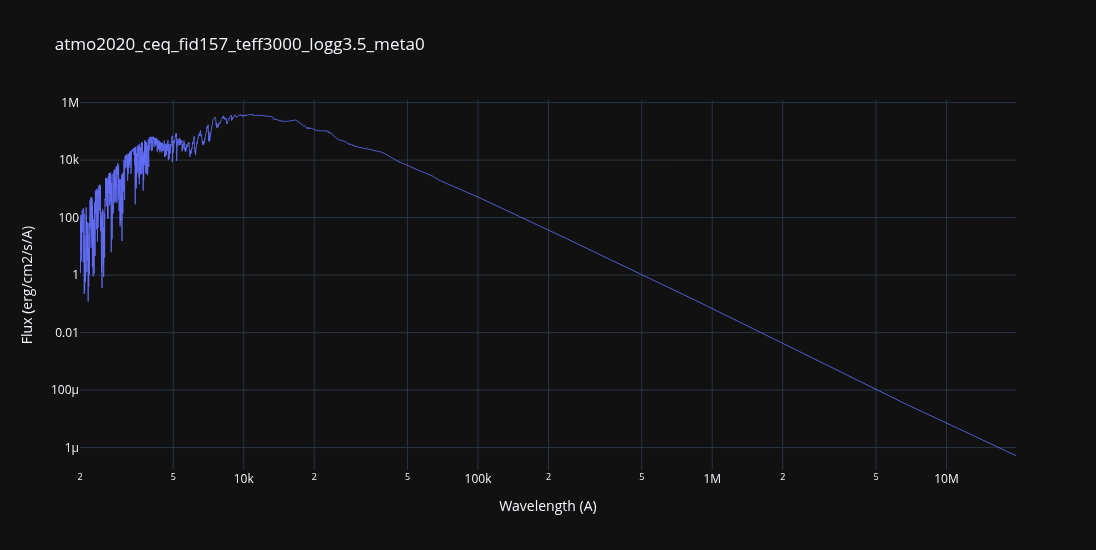

1 spectra visualized

[AMES-Cond 2000] — searching spectra in range...
   44 spectra found. Downloading all...
   [1/44] cond00_fid233_teff3000_logg3.5_meta0.txt
   [2/44] cond00_fid234_teff3000_logg4_meta0.txt
   [3/44] cond00_fid235_teff3000_logg4.5_meta0.txt
   [4/44] cond00_fid236_teff3000_logg5_meta0.txt
   [5/44] cond00_fid244_teff3100_logg5_meta0.txt
   [6/44] cond00_fid243_teff3100_logg4.5_meta0.txt
   [7/44] cond00_fid242_teff3100_logg4_meta0.txt
   [8/44] cond00_fid241_teff3100_logg3.5_meta0.txt
   [9/44] cond00_fid252_teff3200_logg5_meta0.txt
   [10/44] cond00_fid251_teff3200_logg4.5_meta0.txt
   [11/44] cond00_fid250_teff3200_logg4_meta0.txt
   [12/44] cond00_fid249_teff3200_logg3.5_meta0.txt
   [13/44] cond00_fid257_teff3300_logg3.5_meta0.txt
   [14/44] cond00_fid258_teff3300_logg4_meta0.txt
   [15/44] cond00_fid259_teff3300_logg4.5_meta0.txt
   [16/44] cond00_fid260_teff3300_logg5_meta0.txt
   [17/44] cond00_fid268_teff3400_logg5_meta0.txt
   [18/44] cond00_fid267_teff340

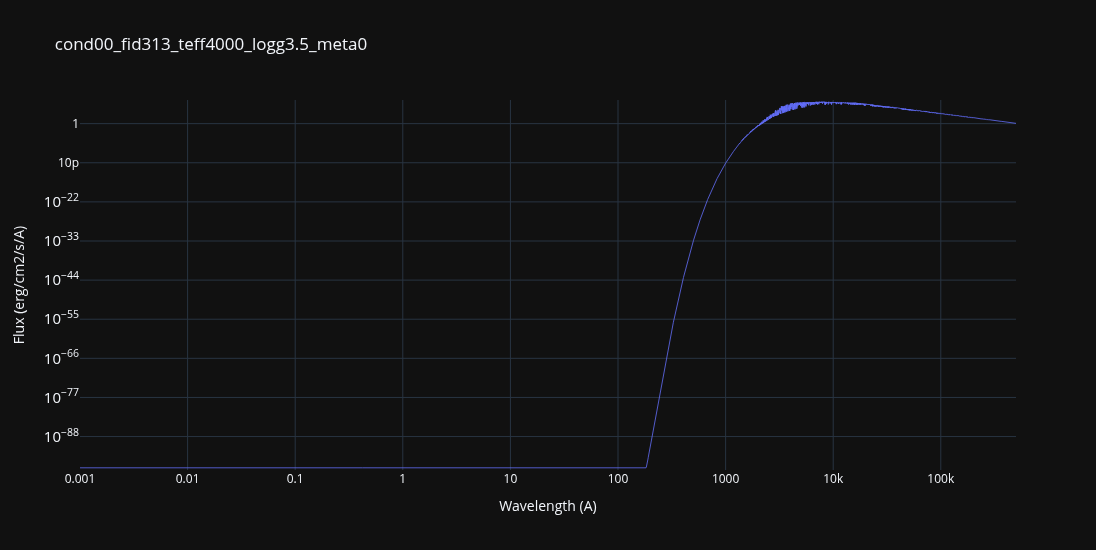

1 spectra visualized


In [9]:
# You can use either the model_id or the collection name as it appears in the table
COLLECTIONS = ['ATMO 2020, CEQ', 'AMES-Cond 2000']   # name or model_id
FORMAT      = 'ascii'         # 'ascii' or 'votable'
CARPETA_SALIDA        = './descargas'
ACCION                = 'ambos'         # 'descargar', 'visualizar' or 'ambos'
MAX_PLOTS             = 1              # number of spectra to visualize
MAX_DOWNLOADS         = 50             # maximum spectra to download — None to download all
 


def get_model_id(name_or_id, df):
    """
    Accepts either a model_id or a collection name (case-insensitive)
    and returns the corresponding model_id.
    """
    if name_or_id in df['model_id'].values:
        return name_or_id
    match = df[df['name'].str.lower() == name_or_id.lower()]
    if not match.empty:
        return match.iloc[0]['model_id']
    return None


def nearest_value(value, options):
    """
    The SVO form only accepts exact values that exist in its lists.
    If the user enters 3200 K but the model only has 3000 and 3500,
    this returns 3000 because it is the closest (difference of 200 vs 300).
    """
    if not options: return str(value)
    try:
        v       = float(value)
        closest = min(options, key=lambda x: abs(x - v))
        return str(int(closest)) if closest == int(closest) else str(closest)
    except (ValueError, TypeError):
        return str(options[0])


def get_spectrum_ids(model_id, teff_min, teff_max, logg_min, logg_max):
    """Fetches the IDs of spectra that match the filter for a given model."""
    col          = df_collections[df_collections['model_id'] == model_id].iloc[0]
    teff_options = col.get('teff_options', []) if isinstance(col, dict) else []
    logg_options = col.get('logg_options', []) if isinstance(col, dict) else []
    data = {
        'models': f',{model_id}',
        f'params[{model_id}][teff][min]': nearest_value(teff_min, teff_options) if teff_min is not None else '',
        f'params[{model_id}][teff][max]': nearest_value(teff_max, teff_options) if teff_max is not None else '',
        f'params[{model_id}][logg][min]': nearest_value(logg_min, logg_options) if logg_min is not None else '',
        f'params[{model_id}][logg][max]': nearest_value(logg_max, logg_options) if logg_max is not None else '',
        'nres': 'all', 'boton': 'Search'
    }
    resp = requests.post(BASE_URL, data=data, timeout=30)
    soup = BeautifulSoup(resp.text, 'html.parser')
    fids, seen = [], set()
    for a in soup.find_all('a', href=True):
        href = a.get('href', '')
        if 'ssap.php' in href and 'format=votable' in href:
            # Each spectrum has two links (ASCII and VOTable) with the same fid.
            # We filter by votable only to avoid processing the same id twice.
            for part in href.split('&'):
                if part.startswith('fid='):
                    fid = part.split('=')[1]
                    if fid not in seen:
                        fids.append(fid)
                        seen.add(fid)
    return fids


def download_spectrum(model_id, fid, fmt, output_dir):
    """Downloads a single spectrum and names it with Teff, logg and metallicity."""
    ext  = 'xml' if fmt == 'votable' else 'txt'
    url  = f'{SSAP_URL}?model={model_id}&fid={fid}&format={fmt}'
    # Temporary name while downloading
    tmp_path = os.path.join(output_dir, f'{model_id}_fid{fid}.{ext}')
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        with open(tmp_path, 'wb') as f:
            f.write(resp.content)

        # Read parameters from ASCII header and rename
        if fmt == 'ascii':
            teff, logg, meta = None, None, 0.0
            with open(tmp_path, 'r') as f:
                for line in f:
                    if not line.startswith('#'): break
                    if 'teff' in line.lower():
                        m = re.search(r'=\s*([\d.]+)', line)
                        if m: teff = float(m.group(1))
                    elif 'logg' in line.lower():
                        m = re.search(r'=\s*([\d.]+)', line)
                        if m: logg = float(m.group(1))
                    elif 'meta' in line.lower():
                        m = re.search(r'=\s*(-?[\d.]+)', line)
                        if m: meta = float(m.group(1))

            if teff is not None and logg is not None and meta is not None:
                new_name = f'{model_id}_fid{fid}_teff{teff:g}_logg{logg:g}_meta{meta:g}.{ext}'
                new_path = os.path.join(output_dir, new_name)
                os.rename(tmp_path, new_path)
                return new_path

        return tmp_path
    except Exception as e:
        print(f'   Error downloading fid={fid}: {e}')
        return None


os.makedirs(CARPETA_SALIDA, exist_ok=True)

def get_spectrum_ids_with_params(model_id, teff_min, teff_max, logg_min, logg_max):
    """
    Same as get_spectrum_ids but also returns the Teff of each spectrum.
    Results are sorted by proximity to the center of the search range,
    so the most representative spectra appear first.
    """
    col          = df_collections[df_collections['model_id'] == model_id].iloc[0]
    teff_options = col.get('teff_options', []) if isinstance(col, dict) else []
    logg_options = col.get('logg_options', []) if isinstance(col, dict) else []

    data = {
        'models': f',{model_id}',
        f'params[{model_id}][teff][min]': nearest_value(teff_min, teff_options) if teff_min is not None else '',
        f'params[{model_id}][teff][max]': nearest_value(teff_max, teff_options) if teff_max is not None else '',
        f'params[{model_id}][logg][min]': nearest_value(logg_min, logg_options) if logg_min is not None else '',
        f'params[{model_id}][logg][max]': nearest_value(logg_max, logg_options) if logg_max is not None else '',
        'nres': 'all', 'boton': 'Search'
    }
    resp = requests.post(BASE_URL, data=data, timeout=30)
    soup = BeautifulSoup(resp.text, 'html.parser')

    espectros = []
    seen      = set()
    for table in soup.find_all('table'):
        celdas = [td.get_text(strip=True) for td in table.find_all('td')]
        if 'Model' in celdas and 'Teff' in celdas and 'VOtable' in str(table):
            for row in table.find_all('tr'):
                cols_row = [td.get_text(strip=True) for td in row.find_all('td')]
                fid = None
                for a in row.find_all('a', href=True):
                    href = a.get('href', '')
                    if 'ssap.php' in href and 'format=votable' in href:
                        for part in href.split('&'):
                            if part.startswith('fid='):
                                fid = part.split('=')[1]
                if fid and fid not in seen and len(cols_row) >= 3:
                    try:
                        teff_val = float(cols_row[1])
                        espectros.append({'fid': fid, 'teff': teff_val})
                        seen.add(fid)
                    except (ValueError, IndexError):
                        pass

    # Sort by proximity to the center of the search range (Teff only)
    if teff_min is not None and teff_max is not None:
        centro = (teff_min + teff_max) / 2
        espectros.sort(key=lambda x: abs(x['teff'] - centro))

    return espectros

for name_or_id in COLLECTIONS:
    model_id = get_model_id(name_or_id, df_collections)
    if model_id is None:
        print(f'Collection "{name_or_id}" not found.')
        print(f'Available collections: {list(df_collections.name)}')
        continue

    col_name = df_collections[df_collections['model_id'] == model_id].iloc[0]['name']
    print(f'\n[{col_name}] — searching spectra in range...')

    if ACCION in ('descargar', 'ambos'):
        fids = get_spectrum_ids(model_id, TEFF_MIN, TEFF_MAX, LOGG_MIN, LOGG_MAX)
        if not fids:
            print(f'   No spectra found for that range.')
            continue

        # Limit downloads if MAX_DOWNLOADS is set
        fids_a_descargar = fids[:MAX_DOWNLOADS] if MAX_DOWNLOADS else fids
        if MAX_DOWNLOADS and len(fids) > MAX_DOWNLOADS:
            print(f'   {len(fids)} spectra found. Downloading the first {MAX_DOWNLOADS} '
                  f'(set MAX_DOWNLOADS=None to download all)...')
        else:
            print(f'   {len(fids)} spectra found. Downloading all...')

        descargados = 0
        for i, fid in enumerate(fids_a_descargar):
            path = download_spectrum(model_id, fid, FORMAT, CARPETA_SALIDA)
            if path:
                descargados += 1
                print(f'   [{i+1}/{len(fids_a_descargar)}] {os.path.basename(path)}')
            time.sleep(0.2)
        print(f'\n   {descargados}/{len(fids_a_descargar)} spectra downloaded to "{CARPETA_SALIDA}"')

    if ACCION in ('visualizar', 'ambos'):
        print(f'\nFetching the {MAX_PLOTS} spectra closest to the search range...')
        espectros = get_spectrum_ids_with_params(model_id, TEFF_MIN, TEFF_MAX, LOGG_MIN, LOGG_MAX)
        if not espectros:
            print('   No spectra found to visualize.')
        else:
            visualize_spectra(model_id, espectros, CARPETA_SALIDA, MAX_PLOTS, TEFF_MIN, TEFF_MAX)

---
## Req 3: Direct query in a single cell

All in one step: filter collections, display the table, and download the spectra of the specified model.

In [10]:
# ── All parameters in one place ───────────────────────────────────────────────
COLLECTION   = 'BT-Settl'      # collection name or model_id
TEFF         = (3000, 7000)    # temperature range (min, max) in K
LOGG         = (3.5,  5.0)     # log(g) range (min, max)
MET          = (-1.0, 0.5)     # metallicity range (min, max)
FORMAT       = 'ascii'         # 'ascii' or 'votable'
OUTPUT_DIR   = './descargas'
MAX_DOWNLOAD = 50              # maximum spectra to download — None to download all
# ─────────────────────────────────────────────────────────────────────────────

# Load collections from API / json
df_direct = pd.DataFrame(load_from_json())

# Step 1 — filter collections
mask_direct = df_direct.apply(lambda r: (
    ranges_overlap(r.teff_min, r.teff_max, TEFF[0], TEFF[1]) and
    ranges_overlap(r.logg_min, r.logg_max, LOGG[0], LOGG[1]) and
    ranges_overlap(r.feh_min,  r.feh_max,  MET[0],  MET[1])
), axis=1)
df_direct = df_direct[mask_direct].reset_index(drop=True)

# Step 2 — display table
df_direct['Teff (K)'] = df_direct.apply(lambda r: fmt_range(r.teff_min, r.teff_max), axis=1)
df_direct['log(g)']   = df_direct.apply(lambda r: fmt_range(r.logg_min, r.logg_max), axis=1)
df_direct['[M/H]']    = df_direct.apply(lambda r: fmt_range(r.feh_min,  r.feh_max),  axis=1)
df_direct['Link']     = df_direct['url'].apply(lambda u: f'<a href="{u}" target="_blank">View</a>')
df_direct.index += 1

print(f'collection={COLLECTION} · Teff={TEFF} · log(g)={LOGG} · [M/H]={MET} · format={FORMAT}')
print(f'\n{len(df_direct)} collections in range:\n')
display(HTML(df_direct[['name','Teff (K)','log(g)','[M/H]','Link']].rename(
    columns={'name':'Collection'}).to_html(escape=False, index=True)))

# Step 3 — download spectra for the selected collection
model_id = get_model_id(COLLECTION, df_direct.rename(columns={'name':'name'}))
if model_id is None:
    print(f'\nCollection "{COLLECTION}" not found in the filtered results.')
    print(f'Available: {list(df_direct.name)}')
else:
    print(f'\nDownloading spectra from "{COLLECTION}" in {FORMAT} format...')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fids = get_spectrum_ids(model_id, TEFF[0], TEFF[1], LOGG[0], LOGG[1])
    if not fids:
        print('   No spectra found for that range.')
    else:
        fids_to_download = fids[:MAX_DOWNLOAD] if MAX_DOWNLOAD else fids
        if MAX_DOWNLOAD and len(fids) > MAX_DOWNLOAD:
            print(f'   {len(fids)} spectra found. Downloading the first {MAX_DOWNLOAD} '
                  f'(set MAX_DOWNLOAD=None to download all)...')
        else:
            print(f'   {len(fids)} spectra found. Downloading all...')

        descargados = 0
        for i, fid in enumerate(fids_to_download):
            path = download_spectrum(model_id, fid, FORMAT, OUTPUT_DIR)
            if path:
                descargados += 1
                print(f'   [{i+1}/{len(fids_to_download)}] {os.path.basename(path)}')
            time.sleep(0.2)
        print(f'\n   {descargados}/{len(fids_to_download)} spectra downloaded to "{OUTPUT_DIR}"')

collection=BT-Settl · Teff=(3000, 7000) · log(g)=(3.5, 5.0) · [M/H]=(-1.0, 0.5) · format=ascii

22 collections in range:



,Collection,Teff (K),log(g),[M/H],Link
1,AMES-Cond 2000,100 – 4000,2.5 – 6,0,View
2,AMES-Dusty 2000,500 – 3900,3.5 – 6,0,View
3,"ATMO 2020, CEQ",200 – 3000,2.5 – 5.5,0,View
4,BT-COND,800 – 70000,-0.5 – 6,-4 – 0.5,View
5,BT-DUSTY,1000 – 70000,-0.5 – 6,-4 – 0.5,View
6,BT-NextGen (AGSS2009),800 – 70000,-0.5 – 6,-4 – 0.5,View
7,BT-NextGen (GNS93),800 – 9800,-0.5 – 5.5,-1.5 – 0.3,View
8,BT-Settl,400 – 70000,-0.5 – 6,-4 – 0.5,View
9,BT-Settl (AGSS2009),400 – 70000,-0.5 – 6,-4 – 0.5,View
10,BT-Settl (CIFIST),1200 – 7000,2.5 – 5.5,0,View



   2058 spectra found. Downloading the first 50 (set MAX_DOWNLOAD=None to download all)...
   [1/50] bt-settl_fid762_teff3000_logg3.5_meta0.txt
   [2/50] bt-settl_fid763_teff3000_logg3.5_meta0.3.txt
   [3/50] bt-settl_fid764_teff3000_logg3.5_meta0.5.txt
   [4/50] bt-settl_fid765_teff3000_logg3.5_meta-0.5.txt
   [5/50] bt-settl_fid766_teff3000_logg3.5_meta-1.txt
   [6/50] bt-settl_fid767_teff3000_logg3.5_meta-1.5.txt
   [7/50] bt-settl_fid768_teff3000_logg3.5_meta-2.txt
   [8/50] bt-settl_fid769_teff3000_logg3.5_meta-2.5.txt
   [9/50] bt-settl_fid770_teff3000_logg3.5_meta-3.txt
   [10/50] bt-settl_fid771_teff3000_logg3.5_meta-3.5.txt
   [11/50] bt-settl_fid772_teff3000_logg3.5_meta-4.txt
   [12/50] bt-settl_fid773_teff3000_logg4_meta0.txt
   [13/50] bt-settl_fid774_teff3000_logg4_meta0.txt
   [14/50] bt-settl_fid775_teff3000_logg4_meta0.txt
   [15/50] bt-settl_fid776_teff3000_logg4_meta0.3.txt
   [16/50] bt-settl_fid777_teff3000_logg4_meta-0.5.txt
   [17/50] bt-settl_fid778_teff3000_lo